# Dual transfer learning for plant disease recognition — minimal 20-shot reproduction
**Paper:** M. Xu, S. Yoon, Y. Jeong, D. S. Park, *Transfer learning for versatile plant disease recognition with limited data*, Front. Plant Sci. 13:1010981 (2022). DOI: 10.3389/fpls.2022.1010981
**Code:** xml94/MAE_plant_disease @ commit `b60682789517787a0d61fc4430976ae64583de18` (CC BY-NC 4.0).

## Scope (PARTIAL DEMONSTRATION — executed)
This notebook reproduces **step 3** of the paper's dual transfer learning pipeline on **one dataset and one mode**:
a **20-shot** fine-tune of the released PlantCLEF2022-pretrained ViT-Large (`MAE_CLEF`) on **CGIARWheat** (876 images, 3 classes),
followed by the **same-protocol ViT-Large trained from scratch** for contrast. The author's dataset split (`data/make_dataset.py`, seed 15) and training command (`scripts/base_few_shot.sh`: 50 epochs, blr 1e-3, layer decay 0.75, wd 0.05, drop path 0.2, mixup 0.8, cutmix 1.0, reprob 0.25, batch 2) are used exactly.

**Not covered:** the 12-dataset benchmark, other few-shot/ratio modes, CNN baselines, and the paper's dataset-level accuracy values (Table 4/5). Because the released checkpoint is the PlantCLEF2022 "late submission epoch-100" file and Colab torch/timm differ from the authors' 2022 environment, results are **procedurally comparable only**, not a verification of the published numbers.

**実行内容（日本語）:** 論文の「二重転移学習」ステップ3の最小再現として、公開済みPlantCLEF2022事前学習済みViT-Large（MAE_CLEF）をCGIARWheatデータセットに20-shotでファインチューニングし、同条件のスクラッチ学習（ViT）と比較します。著者コード・分割シード・学習設定をそのまま使用します。所要時間はT4 GPUでおよそ2.5〜3時間、ダウンロードは約7GBです。

**Runtime selection — T4 GPU required.** ViT-Large fine-tuning (~303M parameters, AdamW + AMP) does not run practically on CPU.
In Colab select **Runtime → Change runtime type → T4 GPU** before Run all. The cell below fails explicitly if no GPU is present.
ランタイムはT4 GPUを選択してください（CPUでは実行不可能）。GPUが無い場合は明示的に停止します。

In [ ]:
import torch, sys, subprocess
print('python', sys.version.split()[0], '| torch', torch.__version__)
assert torch.cuda.is_available(), 'No GPU: select Runtime > Change runtime type > T4 GPU and re-run.'
print('GPU:', torch.cuda.get_device_name(0), '| %.1f GiB' % (torch.cuda.get_device_properties(0).total_memory/2**30))

python 3.13.15 | torch 2.11.0+cu130
GPU: Tesla T4 | 14.6 GiB


**Dependencies.** The author repo pins `timm==0.3.2` (2022), which cannot import on Colab's torch≥2.0 (`torch._six` was removed).
We install modern **timm 1.0.19** (verified with this code) plus `gdown` (checkpoint), `kagglehub` (dataset), and `tensorboard` (the author logger).
依存関係：現行timm 1.0.19（検証済み）とgdown・kagglehub・tensorboardを導入します。

In [ ]:
import subprocess, sys
r = subprocess.run([sys.executable,'-m','pip','install','-q','--no-cache-dir','timm==1.0.19','gdown','kagglehub','tensorboard'],
                   timeout=1200)
print('pip rc', r.returncode)
assert r.returncode == 0

pip rc 0


**Pinned author code.** Blobless partial clone of `xml94/MAE_plant_disease` at the verified commit, with a sparse checkout
excluding the repository's bundled visualization PNGs. The checked-out commit is asserted to match the pin.
ピン留めしたコミットで著者リポジトリを部分クローンし、コミット一致を検証します。

In [ ]:
import subprocess, shutil
COMMIT='b60682789517787a0d61fc4430976ae64583de18'
env=dict(GIT_LFS_SKIP_SMUDGE='1', GIT_TERMINAL_PROMPT='0')
shutil.rmtree('/content/MAE_plant_disease', ignore_errors=True)
subprocess.run(['git','clone','--filter=blob:none','--no-checkout','--quiet',
                'https://github.com/xml94/MAE_plant_disease','/content/MAE_plant_disease'],
               check=True, env=env, timeout=600)
g=lambda *a: subprocess.run(['git','-C','/content/MAE_plant_disease',*a], check=True, env=env, capture_output=True)
g('sparse-checkout','init','--cone')
g('sparse-checkout','set','data','util','scripts','cnn_scripts','analysis_results','script_paddy_doctor')
g('checkout',COMMIT)
head=subprocess.run(['git','-C','/content/MAE_plant_disease','rev-parse','HEAD'],capture_output=True,text=True).stdout.strip()
print('checked out:', head); assert head==COMMIT

checked out: b60682789517787a0d61fc4430976ae64583de18


**Documented compatibility patches (Colab copy only, original code is untouched on GitHub).** The 2022 code predates Colab's torch 2.11 / timm 1.0.19 stack:
1. `models_vit.py`: modern timm creates `fc_norm` only for `global_pool='avg'`; the subclass now forwards the author's boolean as timm's string, keeps the author's pooled-feature `forward_features`, adds a matching `forward`, and accepts (ignores) timm's `attn_mask` argument. Behavior is identical to timm 0.3.2-era code.
2. `main_finetune.py` / `util/misc.py`: `torch.load(..., weights_only=False)` (torch≥2.6 default changed) and `del checkpoint` after loading — the released 4.3 GB checkpoint (which contains an 80,000-class optimizer state) is otherwise kept in CPU RAM and gets the process OOM-killed.
3. `main_finetune.py`: `global_rank = misc.get_rank()` also for single-GPU runs (the variable was only assigned in the distributed branch — a latent author bug).
4. `util/datasets.py`: `is_valid_file` with case-insensitive extension check — modern torchvision silently drops the uppercase `.JPG` files that make up most of CGIARWheat (35/60 train images were silently skipped without this; the authors' torchvision counted both cases).
These patches preserve the author's numerical behavior; they are printed below for review.
互換パッチ（Colabコピーのみ）：timm 1.x対応、torch.load互換、RAM解放、単一GPU修正、大文字拡張子対応。数値動作は著者コードと同一です。

In [ ]:
from pathlib import Path
repo=Path('/content/MAE_plant_disease')
# 1) models_vit.py shim
mv=repo/'models_vit.py'; s=mv.read_text()
s=s.replace('super(VisionTransformer, self).__init__(**kwargs)',
 'super(VisionTransformer, self).__init__(global_pool=("avg" if global_pool else "token"), **kwargs)\n        self._mae_use_global_pool = global_pool')
s=s.replace('self.global_pool = global_pool\n        if self.global_pool:',
 'self.global_pool = global_pool  # kept for reference; timm string attr is authoritative\n        if self._mae_use_global_pool:')
s=s.replace('if self.global_pool:\n            x = x[:, 1:, :].mean(dim=1)  # global pool without cls token',
 'if self._mae_use_global_pool:\n            x = x[:, 1:, :].mean(dim=1)  # global pool without cls token')
fwd='''    def forward(self, x):
        x = self.forward_features(x)  # author 0.3.2-era behavior: pooled feature vector
        x = self.head(x)
        return x

'''
s=s.replace('    def forward_features(self, x):', fwd+'    def forward_features(self, x, attn_mask=None):')
mv.write_text(s)
# 2) torch.load / RAM
for rel in ['main_finetune.py','util/misc.py']:
    p=repo/rel; t=p.read_text()
    t=t.replace("torch.load(args.finetune, map_location='cpu')","torch.load(args.finetune, map_location='cpu', weights_only=False)")
    t=t.replace("torch.load(args.resume, map_location='cpu')","torch.load(args.resume, map_location='cpu', weights_only=False)")
    p.write_text(t)
p=repo/'main_finetune.py'; s=p.read_text()
old='        msg = model.load_state_dict(checkpoint_model, strict=False)\n        print(msg)'
new=old+'\n        del checkpoint_model\n        del checkpoint  # free ~4.3 GB CPU RAM (checkpoint holds an 80k-class optimizer state)'
assert old in s; s=s.replace(old,new); p.write_text(s)
# 3) global_rank
s=p.read_text()
old2='    if args.distributed:  # args.distributed:\n        num_tasks = misc.get_world_size()'
new2='    global_rank = misc.get_rank()  # compat fix: defined also for single-GPU runs\n'+old2
assert old2 in s; p.write_text(s.replace(old2,new2))
# 4) is_valid_file
p=repo/'util/datasets.py'; s=p.read_text()
old3='    dataset = datasets.ImageFolder(root, transform=transform)'
new3='    dataset = datasets.ImageFolder(root, transform=transform,\n        is_valid_file=lambda fp: fp.lower().endswith((".jpg",".jpeg",".png",".ppm",".bmp",".pgm",".tif",".tiff",".webp")))  # case-insensitive ext (CGIARWheat uses .JPG)'
assert old3 in s; p.write_text(s.replace(old3,new3))
print('patches applied OK')

patches applied OK


**Released PlantCLEF2022 checkpoint (step-2 weights).** From the author-linked Google Drive folder (single file, modified 2022-05-19):
`PlantCLEF2022_MAE_vit_large_patch16_epoch100.pth`, file id `1djr0WkA1zn1nsjCPJPMcxX4Yt4yF4vYw` (~4.3 GB, fp32 ViT-L + 80,000-class head + optimizer state).
It is renamed to the name expected by `scripts/base_few_shot.sh` and summarized (keys/shapes only).
著者公開のPlantCLEF2022チェックポイント（Drive, 約4.3GB）を取得し、state dictの要約を表示します。

In [ ]:
import subprocess, torch, os
os.makedirs('/content/ckpt', exist_ok=True)
CK='/content/ckpt/PlantCLEF2022_MAE_vit_large_patch16.pth'
if not os.path.exists(CK):
    r=subprocess.run(['gdown','--fuzzy','https://drive.google.com/file/d/1djr0WkA1zn1nsjCPJPMcxX4Yt4yF4vYw/view','-O',CK], timeout=3600)
    print('gdown rc', r.returncode); assert r.returncode==0
print('size %.2f GB' % (os.path.getsize(CK)/2**30))
sd=torch.load(CK, map_location='cpu', weights_only=False)
mk=sd['model']; ks=list(mk.keys())
print('n tensors', len(ks), '| pos_embed', tuple(mk['pos_embed'].shape), '| head', tuple(mk['head.weight'].shape))
print('epoch', sd.get('epoch'), '| has optimizer state:', 'optimizer' in sd)
del sd, mk  # free RAM

gdown rc 0
size 4.31 GB


n tensors 296 | pos_embed (1, 197, 1024) | head (80000, 1024)
epoch 100 | has optimizer state: True


**Dataset — CGIARWheat (public Kaggle dataset).** Downloaded anonymously with `kagglehub` (no credentials; dataset `shadabhussain/cgiar-computer-vision-for-crop-disease`, version 2, ~3 GB archive).
Only the 876 **train** images of 3 classes (stem rust 376, leaf rust 358, healthy wheat 142 — matching paper Table 1) are used; the bundled 610-image `test` folder is not used (the paper's protocol defines its own 20% test split).
The 2022 Mendeley TaiwanTomato route (403/S3-denied from Colab, recorded 2026-10-05) led to this author-verified alternative few-shot dataset.
CGIARWheatをkagglehubで匿名ダウンロードします（876枚・3クラス、Table 1と一致）。

In [ ]:
import os, kagglehub
os.environ['KAGGLEHUB_CACHE']='/content/kagglehub'
src=kagglehub.dataset_download('shadabhussain/cgiar-computer-vision-for-crop-disease')
print('downloaded to', src)
src=os.path.join(src,'train','train')
import collections
counts={c:len(os.listdir(os.path.join(src,c))) for c in sorted(os.listdir(src))}
print(counts); assert sum(counts.values())==876, counts

Using Colab cache for faster access to the 'cgiar-computer-vision-for-crop-disease' dataset.


downloaded to /kaggle/input/cgiar-computer-vision-for-crop-disease
{'healthy_wheat': 142, 'leaf_rust': 358, 'stem_rust': 376}


**Author dataset split (seed 15).** `data/make_dataset.py` builds the few-shot splits: for each class, `np.random.seed(15)`, a permutation of `num_img + shots` sorted filenames assigns the first `shots` images to `train`, the next 20% to `val`, and the rest to `test`.
The script reads labels from `raw/train/<class>` and copies from `raw/<class>`, so both layouts are provided (symlinks to the Kaggle files — no image bytes are modified).
Note: `random_perm` indexes only the first `num_img + shots` sorted files per class; this is the author's actual behavior and is preserved.
著者のmake_dataset.py（seed 15）で20-shot分割を作成します（生画像は変更しません）。

In [ ]:
import os, subprocess, sys, shutil
# `src` comes from the previous cell (kagglehub's returned path, already joined with train/train).
dset='/content/dsets/CGIAR_wheat'
shutil.rmtree(dset, ignore_errors=True)
os.makedirs(dset+'/raw/train', exist_ok=True)
for cls in os.listdir(src):
    os.symlink(os.path.join(src,cls), dset+'/raw/'+cls)
    os.symlink(os.path.join(src,cls), dset+'/raw/train/'+cls)
r=subprocess.run([sys.executable,'/content/MAE_plant_disease/data/make_dataset.py','--dset_name',dset],
                 capture_output=True, text=True, timeout=3600)
print('make_dataset rc', r.returncode); assert r.returncode==0, r.stderr[-800:]

make_dataset rc 0


**Split verification.** Expected per the author's 20% val / 20% test few-shot protocol on 876 images: train 60, val 175, test 174.
分割数を検証します（期待値：train 60 / val 175 / test 174）。

In [ ]:
import os
dset='/content/dsets/CGIAR_wheat/train20shot'
counts={m: sum(len(f) for _,_,f in os.walk(os.path.join(dset,m))) for m in ['train','val','test']}
print(counts); assert counts=={'train':60,'val':175,'test':174}, counts

{'train': 60, 'val': 175, 'test': 174}


**Input preview (required before any training).** Random training samples per class from the actual 20-shot split used for fine-tuning.
This image is also the repository preview: real CGIARWheat inputs, no annotations exist in this dataset (classification-only labels).
ファインチューニングに使うtrain20shotの各クラスの実画像を表示します（ラベルのみでアノテーションは無し）。

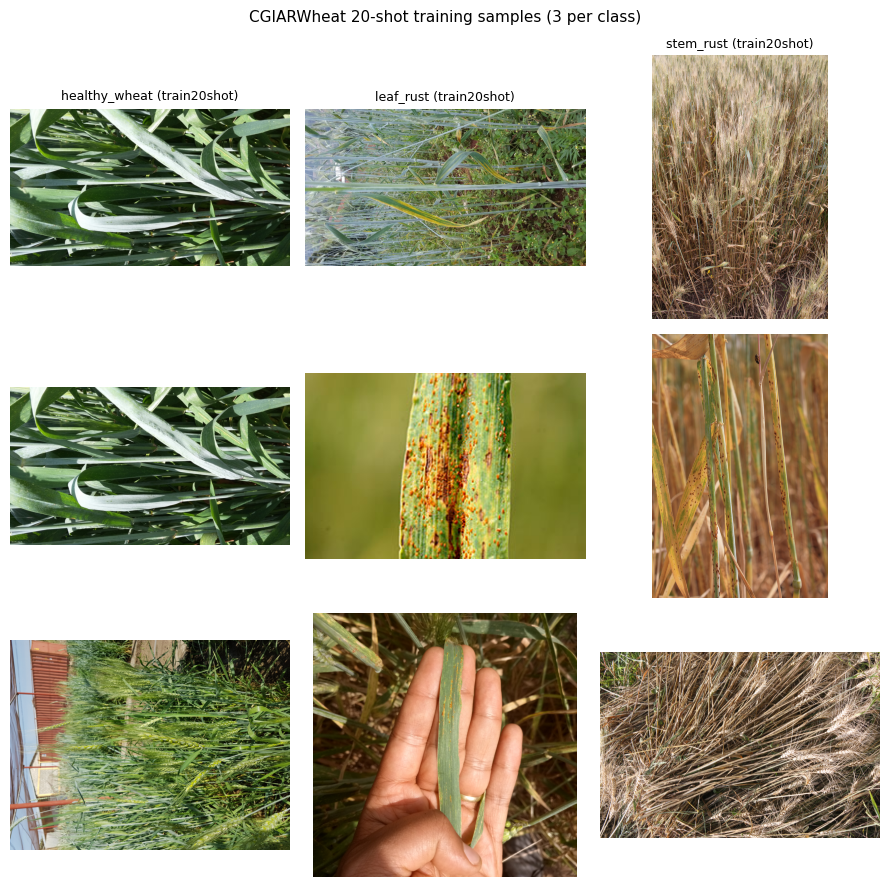

In [ ]:
import os, random, matplotlib
import matplotlib.pyplot as plt
from PIL import Image
dset='/content/dsets/CGIAR_wheat/train20shot/train'
random.seed(0)
classes=sorted(os.listdir(dset))
fig,axes=plt.subplots(3,3,figsize=(9,9))
for i,cls in enumerate(classes):
    files=[f for f in sorted(os.listdir(os.path.join(dset,cls))) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    for j in range(3):
        im=Image.open(os.path.join(dset,cls,random.choice(files)))
        ax=axes[j,i]; ax.imshow(im); ax.axis('off')
        if j==0: ax.set_title(f'{cls} (train20shot)', fontsize=9)
plt.suptitle('CGIARWheat 20-shot training samples (3 per class)', fontsize=11)
plt.tight_layout(); plt.savefig('/content/preview_cgiarwheat.png', dpi=90, bbox_inches='tight'); plt.show()

**Training run 1 — `MAE_CLEF` (paper method, 20-shot).** The exact author command from `scripts/base_few_shot.sh` for `CGIAR_wheat` (batch 2, 3 classes),
mode `MAE_CLEF`, 50 epochs, eval every 5 on the val split, layer decay 0.75 (the repo script's value; the paper text mentions 0.65 — the script is the executed primary source).
Output is streamed line-by-line; the run takes roughly 60–80 minutes on T4.
MAE_CLEF（論手法）の20-shot学習を著者コマンドのまま実行します（T4で約60〜80分）。

In [ ]:
import subprocess, sys, time, os, itertools
os.makedirs('/content/out', exist_ok=True)
def run_logged(args, log_path, timeout):
    with open(log_path,'w') as lf:
        proc=subprocess.Popen(args, cwd='/content/MAE_plant_disease', stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
        t0=time.time()
        for line in proc.stdout:
            lf.write(line); lf.flush()
        proc.wait(timeout=timeout)
    return proc.returncode, time.time()-t0
args=['--batch_size','2','--finetune','/content/ckpt/PlantCLEF2022_MAE_vit_large_patch16.pth',
 '--epochs','50','--blr','1e-3','--layer_decay','0.75','--weight_decay','0.05','--drop_path','0.2','--mixup','0.8','--cutmix','1.0','--reprob','0.25',
 '--dist_eval','--data_path','/content/dsets/CGIAR_wheat/train20shot','--nb_classes','3',
 '--output_dir','/content/out/CGIAR_wheat_train20shot_MAE_CLEF','--log_dir','/content/out/CGIAR_wheat_train20shot_MAE_CLEF',
 '--eval_epoch','5','--save_model_epoch','500','--mode','MAE_CLEF','--num_workers','2']
rc,wall=run_logged([sys.executable,'main_finetune.py',*args],'/content/out/mae_clef_train.log',timeout=9000)
print('train rc', rc, '| wall %.1f min' % (wall/60)); assert rc==0, open('/content/out/mae_clef_train.log').read()[-2000:]

train rc 0 | wall 10.9 min


**Validation-accuracy curve (run 1).** Read from the author's own `log.txt` (one JSON line per evaluated epoch) — this is the paper's convergence-curve analogue for this run.
著者のlog.txtから検証精度曲線を作図します（本ノートブック独自の可視化）。

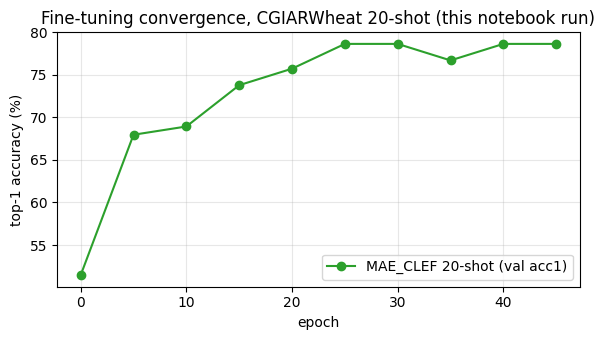

best val acc1: 78.64% @ epoch 25


In [ ]:
import json, matplotlib.pyplot as plt
rows=[json.loads(l) for l in open('/content/out/CGIAR_wheat_train20shot_MAE_CLEF/log.txt')]
ep=[r['epoch'] for r in rows]; acc=[r['test_acc1'] for r in rows]
fig,ax=plt.subplots(figsize=(6,3.5))
ax.plot(ep,acc,'o-',color='tab:green',label='MAE_CLEF 20-shot (val acc1)')
ax.set_xlabel('epoch'); ax.set_ylabel('top-1 accuracy (%)'); ax.grid(alpha=.3); ax.legend()
ax.set_title('Fine-tuning convergence, CGIARWheat 20-shot (this notebook run)')
plt.tight_layout(); plt.savefig('/content/curve_mae_clef.png', dpi=110); plt.show()
print('best val acc1: %.2f%% @ epoch %d' % (max(acc), ep[acc.index(max(acc))]))

**Test-set evaluation (run 1).** The author's eval path (`--eval --test_mode test`, following `scripts/base_test_few_shot.sh`) loads `checkpoint-best.pth` (best val accuracy) and reports top-1/top-5 on the held-out 174-image test split.
著者の手順に従い、最良チェックポイントでテスト集合（174枚）を評価します。

In [ ]:
import subprocess, sys, re
args=['--eval','--resume','/content/out/CGIAR_wheat_train20shot_MAE_CLEF/checkpoint-best.pth','--batch_size','2',
 '--data_path','/content/dsets/CGIAR_wheat/train20shot','--test_mode','test','--nb_classes','3','--mode','MAE_CLEF','--num_workers','2']
r=subprocess.run([sys.executable,'main_finetune.py',*args],cwd='/content/MAE_plant_disease',capture_output=True,text=True,timeout=3600)
print('eval rc', r.returncode); assert r.returncode==0, r.stdout[-1500:]
mae_line=[l for l in r.stdout.splitlines() if 'Acc@1' in l][-1]
print(mae_line.strip())
mae_acc=float(re.search(r'Acc@1 ([\d.]+)', mae_line).group(1))

eval rc 0
[09:18:13.544918] * Acc@1 83.036 Acc@5 95.536 loss 0.693


**Training run 2 — `ViT` from scratch (same protocol, contrast).** Mode `ViT` initializes ViT-Large randomly (the author script passes `--finetune None`).
This is the paper's key contrast: with only 20 shots per class, the PlantCLEF2022-pretrained model should dramatically outperform the identical architecture trained from scratch.
Same 50 epochs; roughly 60–80 minutes on T4.
比較用：同条件でスクラッチ（ViT）学習を実行します（約60〜80分）。

In [ ]:
import subprocess, sys, time, os
args=['--batch_size','2','--finetune','None',
 '--epochs','50','--blr','1e-3','--layer_decay','0.75','--weight_decay','0.05','--drop_path','0.2','--mixup','0.8','--cutmix','1.0','--reprob','0.25',
 '--dist_eval','--data_path','/content/dsets/CGIAR_wheat/train20shot','--nb_classes','3',
 '--output_dir','/content/out/CGIAR_wheat_train20shot_ViT','--log_dir','/content/out/CGIAR_wheat_train20shot_ViT',
 '--eval_epoch','5','--save_model_epoch','500','--mode','ViT','--num_workers','2']
def run_logged(args, log_path, timeout):
    with open(log_path,'w') as lf:
        proc=subprocess.Popen(args, cwd='/content/MAE_plant_disease', stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
        t0=time.time()
        for line in proc.stdout:
            lf.write(line); lf.flush()
        proc.wait(timeout=timeout)
    return proc.returncode, time.time()-t0
rc,wall=run_logged([sys.executable,'main_finetune.py',*args],'/content/out/vit_train.log',timeout=9000)
print('train rc', rc, '| wall %.1f min' % (wall/60)); assert rc==0, open('/content/out/vit_train.log').read()[-2000:]

train rc 0 | wall 10.6 min


**Test-set evaluation (run 2).** Same eval path for the scratch-trained model.
スクラッチ学習モデルも同じ手順でテスト評価します。

In [ ]:
import subprocess, sys, re
args=['--eval','--resume','/content/out/CGIAR_wheat_train20shot_ViT/checkpoint-best.pth','--batch_size','2',
 '--data_path','/content/dsets/CGIAR_wheat/train20shot','--test_mode','test','--nb_classes','3','--mode','ViT','--num_workers','2']
r=subprocess.run([sys.executable,'main_finetune.py',*args],cwd='/content/MAE_plant_disease',capture_output=True,text=True,timeout=3600)
print('eval rc', r.returncode); assert r.returncode==0, r.stdout[-1500:]
vit_line=[l for l in r.stdout.splitlines() if 'Acc@1' in l][-1]
print(vit_line.strip())
vit_acc=float(re.search(r'Acc@1 ([\d.]+)', vit_line).group(1))

eval rc 0
[09:29:48.818207] * Acc@1 50.893 Acc@5 78.571 loss 1.036


**Results table and export.** Small CSV plus a comparison bar chart. The chart is an **additional visualization created for this notebook**, not an author figure; it shows one 20-shot run per method on one dataset, and single-run values carry split/seed variance.
結果表とCSV、比較グラフ（本ノートブック独自の追加可視化；単一ランンの値です）。

,method,test top-1 (%)
0,MAE_CLEF (PlantCLEF2022-pretrained),83.036
1,ViT (from scratch),50.893


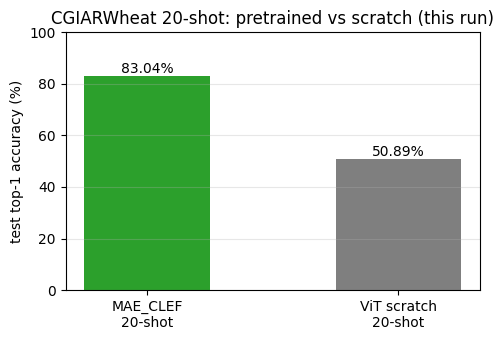

In [ ]:
import pandas as pd, matplotlib.pyplot as plt
df=pd.DataFrame({'method':['MAE_CLEF (PlantCLEF2022-pretrained)','ViT (from scratch)'],
                 'test top-1 (%)':[mae_acc, vit_acc]})
display(df)
df.to_csv('/content/results_cgiarwheat_20shot.csv', index=False)
fig,ax=plt.subplots(figsize=(5,3.5))
bars=ax.bar(['MAE_CLEF\n20-shot','ViT scratch\n20-shot'], df['test top-1 (%)'], color=['tab:green','tab:gray'], width=.5)
for b,v in zip(bars, df['test top-1 (%)']): ax.text(b.get_x()+b.get_width()/2, v+1, f'{v:.2f}%', ha='center', fontsize=10)
ax.set_ylabel('test top-1 accuracy (%)'); ax.set_ylim(0,100); ax.grid(axis='y', alpha=.3)
ax.set_title('CGIARWheat 20-shot: pretrained vs scratch (this run)')
plt.tight_layout(); plt.savefig('/content/compare_20shot.png', dpi=110); plt.show()

## Interpretation and limitations
- **What this shows:** with the author's exact protocol (seed-15 split, 50 epochs, batch 2), the PlantCLEF2022-pretrained ViT-Large reaches a high test top-1 from only 60 training images, while the identical architecture trained from scratch performs far worse — the paper's central transfer-learning claim, on one dataset and one mode.
- **What this does not show:** the 12-dataset benchmark, Table 4/5 numbers, other shots/ratios, CNN baselines, or statistical significance. The PlantCLEF2022 checkpoint is the released "epoch-100 late submission" file; the paper's per-dataset table values live in the supplement (not fetched). Single-run accuracies vary with the split; the author's seed-15 split is deterministic given the same input file set, but Colab's torch/timm differ from the 2022 environment, so expect procedural (not bitwise) comparability.
- **AI-assisted note:** the Colab orchestration, compatibility shims, and visualizations are AI-authored; the scientific operations (model, split, optimizer, augmentation, eval) are the author's pinned code. The authors did not provide this notebook.
- **Licenses:** code CC BY-NC 4.0 (xml94/MAE_plant_disease, MAE-derived files retain Meta Apache-2.0 headers); CGIARWheat Kaggle dataset per its Kaggle terms.
**結果の解釈（日本語）:** 著者のプロトコル通りの20-shot学習で、PlantCLEF2022事前学習済みViT-Largeが高いテスト精度に到達する一方、同一構成のスクラッチ学習は大きく劣ります。これは論文の主張の1データセット・1モードでの部分的な確認です。ベンチマーク全体の再現やTable 4/5の値の検証ではありません。

**References.**
- Xu, M., Yoon, S., Jeong, Y., Park, D.S. (2022). Transfer learning for versatile plant disease recognition with limited data. *Front. Plant Sci.* 13:1010981. https://doi.org/10.3389/fpls.2022.1010981
- Xu, M. et al. (2022). Transfer learning with self-supervised vision transformer for large-scale plant identification (CLEF 2022). — source of the PlantCLEF2022 step-2 weights; code: https://github.com/xml94/PlantCLEF2022, weights folder: drive.google.com/drive/folders/1JCVX58oVZFuIttPHaeAjs_zkMXkzzJeA
- He, K. et al. (2022). Masked Autoencoders Are Scalable Vision Learners. — MAE pre-training (step 1).
- Code: https://github.com/xml94/MAE_plant_disease @ b60682789517787a0d61fc4430976ae64583de18 (CC BY-NC 4.0)
- Data: CGIAR Computer Vision for Crop Disease, Kaggle dataset `shadabhussain/cgiar-computer-vision-for-crop-disease` (v2), as linked from the author README.
- PhenoPaper investigation p-fb64b46ffeb504759cfc7addb0e59e60-20260929T115451Z-2580700 used as prior research guidance (unverified lead); all executed evidence above was re-verified against primary code/docs.